# 06 - Clustering Spotify Songs

Goal: discover natural groups of songs from audio characteristics without using a target variable.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
df = pd.read_csv(DATA_CLEAN)
print(df.shape)

(89741, 23)


## Feature Selection and Scaling

Clustering uses audio features only. The variables are standardized so that tempo or duration do not dominate bounded features such as danceability or acousticness.

In [3]:
cluster_features = [
    "duration_min", "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

X = df[cluster_features].copy()
X_scaled = StandardScaler().fit_transform(X)

sample_size = min(5000, len(df))
sample_idx = df.sample(n=sample_size, random_state=RANDOM_STATE).index
X_sample = X_scaled[sample_idx]
print(f"Clustering sample size for model selection: {sample_size:,}")

Clustering sample size for model selection: 5,000


,k,inertia,silhouette
0,2,38560.554351,0.251775
1,3,34642.219768,0.151013
2,4,31585.095694,0.158549
3,5,28992.210455,0.161700
4,6,26776.062309,0.161366
5,7,24711.712538,0.172202
6,8,23579.356196,0.155018


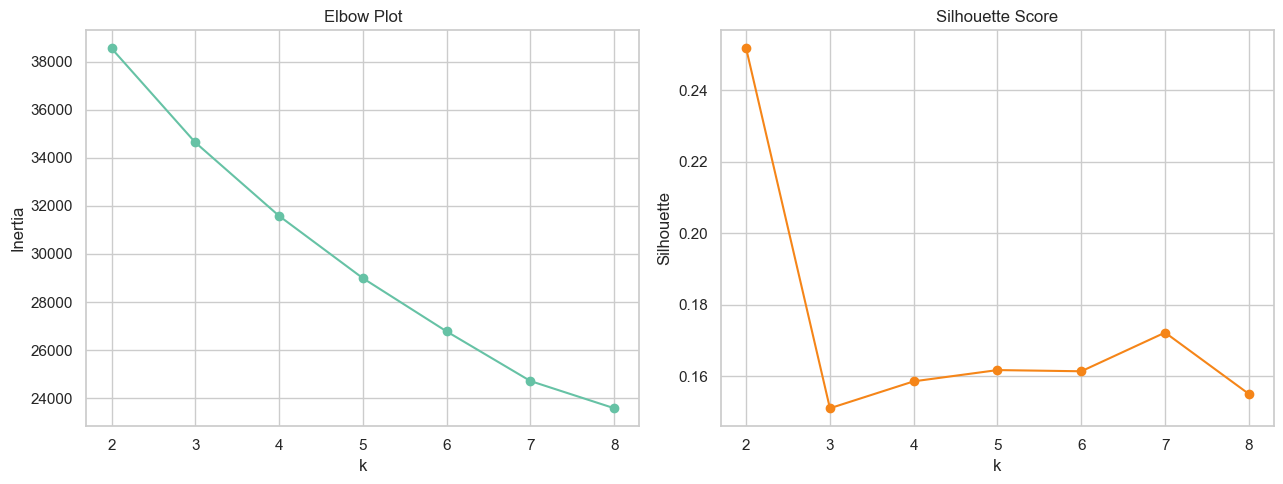

In [4]:
ks = range(2, 9)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, labels))

k_table = pd.DataFrame({"k": list(ks), "inertia": inertias, "silhouette": silhouettes})
display(k_table)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_table["k"], k_table["inertia"], marker="o")
axes[0].set_title("Elbow Plot")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_table["k"], k_table["silhouette"], marker="o", color="#F58518")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [5]:
best_k = int(k_table.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
print(f"Selected k based on highest silhouette score: {best_k}")

final_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = final_kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby("cluster")[cluster_features + ["popularity"]].mean().round(3)
cluster_counts = df["cluster"].value_counts().sort_index().to_frame("count")
display(cluster_counts)
display(cluster_profile)

Selected k based on highest silhouette score: 2


,count
cluster,
0,67499
1,22242


,duration_min,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
cluster,,,,,,,,,,,
0,3.880,0.596,0.746,-6.490,0.097,0.188,0.123,0.229,0.523,126.272,33.969
1,3.633,0.460,0.295,-14.595,0.059,0.753,0.328,0.182,0.307,109.270,30.859


In [6]:
def describe_cluster(row):
    tags = []
    if row["energy"] >= cluster_profile["energy"].median():
        tags.append("energetic")
    if row["danceability"] >= cluster_profile["danceability"].median():
        tags.append("danceable")
    if row["acousticness"] >= cluster_profile["acousticness"].median():
        tags.append("acoustic")
    if row["instrumentalness"] >= cluster_profile["instrumentalness"].median():
        tags.append("instrumental")
    if row["valence"] >= cluster_profile["valence"].median():
        tags.append("positive")
    return ", ".join(tags[:3]) if tags else "balanced"

cluster_labels = cluster_profile.apply(describe_cluster, axis=1).to_frame("suggested_description")
display(cluster_labels)

,suggested_description
cluster,
0,"energetic, danceable, positive"
1,"acoustic, instrumental"


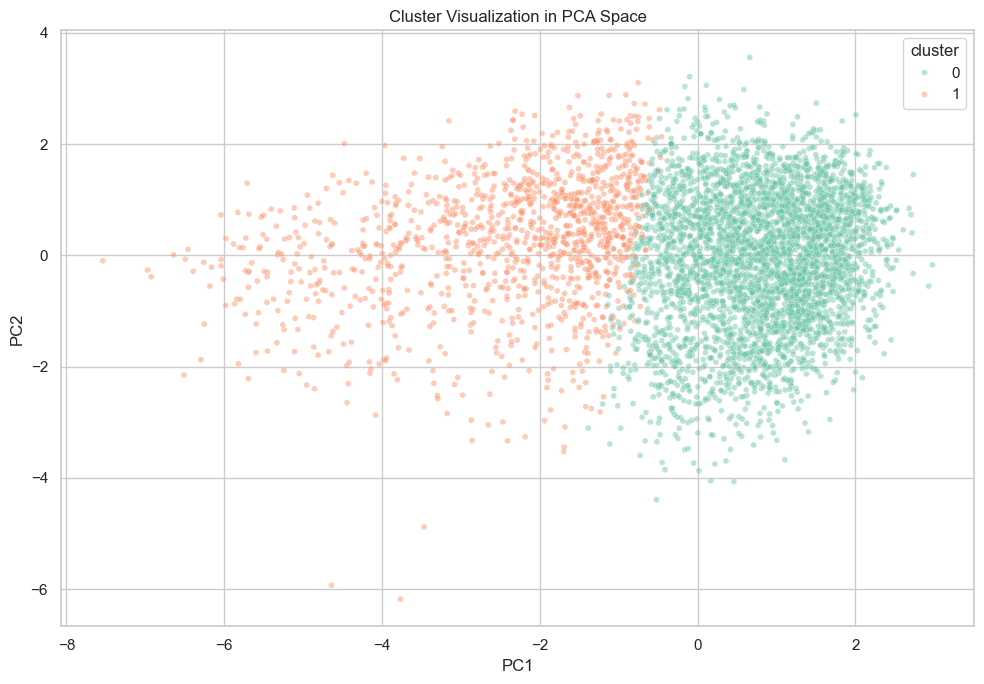

In [7]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca_2d.fit_transform(X_scaled[sample_idx])
plot_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
plot_df["cluster"] = df.loc[sample_idx, "cluster"].astype(str).values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", alpha=0.45, s=18)
plt.title("Cluster Visualization in PCA Space")
plt.tight_layout()
plt.show()

## Clustering Conclusion

The clusters summarize broad song types based on audio properties, such as energetic/danceable, acoustic, instrumental, or balanced groups. These clusters can help Spotify organize catalog exploration, seed playlist concepts, and create interpretable segments for recommendation experiments.